<a href="https://colab.research.google.com/github/m22aie202/FM_GenAI/blob/main/m22aie202_Assignment_3_Attempt_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install transformers datasets accelerate -q

In [38]:
import torch
import torch.nn as nn
from transformers import BertTokenizer, BertModel
from torch.optim import AdamW
from datasets import load_dataset
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
from transformers import logging
from tqdm import tqdm
import os

os.environ["HF_HUB_DISABLE_PROGRESS_BARS"] = "1"
os.environ["HF_HUB_ENABLE_HF_TRANSFER"] = "0"
os.environ["DISABLE_TQDM"] = "1"
os.environ["TRANSFORMERS_VERBOSITY"] = "error"
os.environ["HF_DATASETS_DISABLE_PROGRESS_BAR"] = "1"

tqdm(disable=True)  # disables widget rendering
logging.set_verbosity_error()

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [31]:
dataset = load_dataset("stanfordnlp/sst2")

train_data = dataset["train"].shuffle(seed=42).select(range(10000))
val_size = min(1000, len(dataset["validation"]))
val_data = dataset["validation"].select(range(val_size))

In [32]:
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

def tokenize(batch):
    return tokenizer(
        batch["sentence"],
        padding="max_length",
        truncation=True,
        max_length=128,
        return_tensors="pt"
    )

train_data = train_data.map(tokenize, batched=True)
val_data = val_data.map(tokenize, batched=True)

train_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])
val_data.set_format(type="torch", columns=["input_ids", "attention_mask", "label"])

train_loader = DataLoader(train_data, batch_size=16, shuffle=True)
val_loader = DataLoader(val_data, batch_size=16)

In [33]:
class Adapter(nn.Module):
    def __init__(self, hidden_size, bottleneck=64):
        super(Adapter, self).__init__()
        self.down = nn.Linear(hidden_size, bottleneck)
        self.relu = nn.ReLU()
        self.up = nn.Linear(bottleneck, hidden_size)

    def forward(self, x):
        return x + self.up(self.relu(self.down(x)))  # Residual connection

In [34]:
class BertWithAdapters(nn.Module):
    def __init__(self):
        super().__init__()
        self.bert = BertModel.from_pretrained("bert-base-uncased")
        hidden_size = self.bert.config.hidden_size

        # Freeze base model
        for param in self.bert.parameters():
            param.requires_grad = False

        # Add adapters to each encoder layer
        self.adapters = nn.ModuleList([
            Adapter(hidden_size) for _ in range(len(self.bert.encoder.layer))
        ])

        self.classifier = nn.Linear(hidden_size, 2)

    def forward(self, input_ids, attention_mask):
        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask,
            output_hidden_states=True
        )

        hidden_states = outputs.last_hidden_state

        # Apply adapters layer-wise
        for i, adapter in enumerate(self.adapters):
            hidden_states = adapter(hidden_states)

        cls_output = hidden_states[:, 0]  # CLS token
        logits = self.classifier(cls_output)
        return logits

In [ ]:
model = BertWithAdapters().to(device)

# Count parameters
total_params = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(f"Total Parameters: {total_params}")
print(f"Trainable Parameters: {trainable_params}")

In [8]:
optimizer = AdamW(filter(lambda p: p.requires_grad, model.parameters()), lr=2e-4)
criterion = nn.CrossEntropyLoss()

train_losses = []
val_losses = []

epochs = 3

for epoch in range(epochs):
    model.train()
    total_train_loss = 0

    for batch in train_loader:
        optimizer.zero_grad()

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)

        outputs = model(input_ids, attention_mask)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_train_loss += loss.item()

    avg_train_loss = total_train_loss / len(train_loader)
    train_losses.append(avg_train_loss)

    # Validation
    model.eval()
    total_val_loss = 0

    with torch.no_grad():
        for batch in val_loader:
            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(input_ids, attention_mask)
            loss = criterion(outputs, labels)

            total_val_loss += loss.item()

    avg_val_loss = total_val_loss / len(val_loader)
    val_losses.append(avg_val_loss)

    print(f"Epoch {epoch+1} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch 1 | Train Loss: 0.4413 | Val Loss: 0.6235
Epoch 2 | Train Loss: 0.3859 | Val Loss: 0.3343
Epoch 3 | Train Loss: 0.3748 | Val Loss: 0.3382


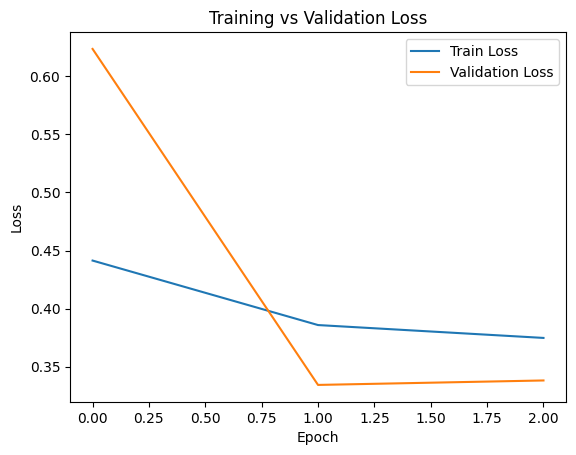

In [9]:
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Validation Loss")
plt.legend()
plt.title("Training vs Validation Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.show()

In [10]:
def predict(sentence):
    model.eval()
    inputs = tokenizer(
        sentence,
        return_tensors="pt",
        truncation=True,
        padding=True,
        max_length=128
    ).to(device)

    with torch.no_grad():
        outputs = model(inputs["input_ids"], inputs["attention_mask"])
        prediction = torch.argmax(outputs, dim=1).item()

    return "Positive" if prediction == 1 else "Negative"


# Example
print(predict("The movie was absolutely fantastic"))
print(predict("Worst film I have ever seen"))

Positive
Negative
